# Quantium Retail Analytics - Task 1
## Customer Segment Anaysis: Chip Purchasing Behavior

This notebook analyzes chip purchasing behavior for a supermarket client. The purpose is to understand which customer segments buy the most chips and the drivers behind the sales, to provide data-driven insight on strategy recommendations.

In [85]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(color_codes=True)


In [111]:
transactions = pd.read_excel('QVI_transaction_data.xlsx')
customers = pd.read_csv('QVI_purchase_behaviour.csv')
print(transactions.shape, customers.shape)

(264836, 8) (72637, 3)


In [87]:
print(transactions.head())
print(customers.head())

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  
   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004  

In [88]:
print(customers.info())
print(customers.isnull().sum())
print(transactions.info())
print(transactions.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7  

## Data Cleaning:
The date column in the transactions dataframe needs to be reformatted to its appropriate data type.

Before a thorough analysis, the check for possible outliers was assessed and dealt with accordingly depending on the context of the data point. Real outliers may represent data errors or an account test rather than an actual customer.

In [89]:
#Fix the DATE column in transactions
transactions['DATE'] = pd.to_datetime(transactions['DATE'])
print(transactions['DATE'].head())
print(transactions['DATE'].min(),transactions['DATE'].max())

0   1970-01-01 00:00:00.000043390
1   1970-01-01 00:00:00.000043599
2   1970-01-01 00:00:00.000043605
3   1970-01-01 00:00:00.000043329
4   1970-01-01 00:00:00.000043330
Name: DATE, dtype: datetime64[ns]
1970-01-01 00:00:00.000043282 1970-01-01 00:00:00.000043646


In [90]:
# Check for outliers in the datasets
print(transactions['PROD_QTY'].describe())
print(transactions['TOT_SALES'].describe(),'\n')
print(transactions['PROD_NAME'].unique())

# Check the maximum value in PROD_QTY and TOT_SALES too see if same person 
print(transactions[transactions['PROD_QTY'] == 200], '\n')

print(transactions[transactions['TOT_SALES'] == transactions['TOT_SALES'].max()])



count    264836.000000
mean          1.907309
std           0.643654
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64
count    264836.000000
mean          7.304200
std           3.083226
min           1.500000
25%           5.400000
50%           7.400000
75%           9.200000
max         650.000000
Name: TOT_SALES, dtype: float64 

['Natural Chip        Compny SeaSalt175g' 'CCs Nacho Cheese    175g'
 'Smiths Crinkle Cut  Chips Chicken 170g'
 'Smiths Chip Thinly  S/Cream&Onion 175g'
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g'
 'Old El Paso Salsa   Dip Tomato Mild 300g'
 'Smiths Crinkle Chips Salt & Vinegar 330g'
 'Grain Waves         Sweet Chilli 210g'
 'Doritos Corn Chip Mexican Jalapeno 150g'
 'Grain Waves Sour    Cream&Chives 210G'
 'Kettle Sensations   Siracha Lime 150g' 'Twisties Cheese     270g'
 'WW Crinkle Cut      Chicken 175g' 'Thins Chips Light&  Tangy 175g'
 'CCs Original 175g'

In [91]:
# Check the customer who bought the 200 units of chips
print(transactions[transactions['PROD_QTY'] == 200]['LYLTY_CARD_NBR'].unique())
print(transactions[transactions['TOT_SALES'] == 650]['LYLTY_CARD_NBR'].unique())
# Same customer so lets see if thats there only transaction
print(transactions[transactions['LYLTY_CARD_NBR'] == 226000],'\nThis is their transaction history')

[226000]
[226000]
                               DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  \
69762 1970-01-01 00:00:00.000043331        226          226000  226201   
69763 1970-01-01 00:00:00.000043605        226          226000  226210   

       PROD_NBR                         PROD_NAME  PROD_QTY  TOT_SALES  
69762         4  Dorito Corn Chp     Supreme 380g       200      650.0  
69763         4  Dorito Corn Chp     Supreme 380g       200      650.0   
This is their transaction history


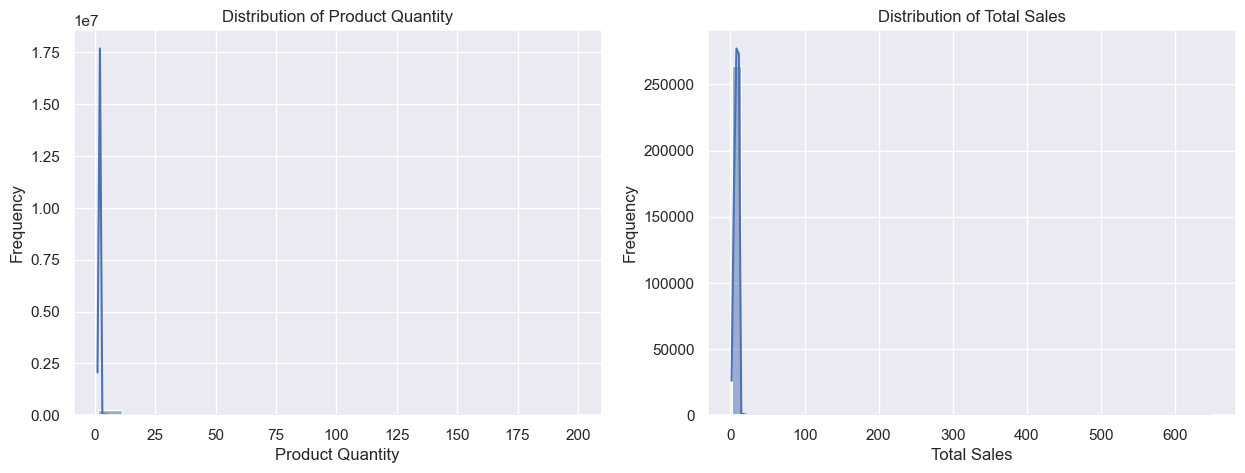

In [92]:
# Before removing the oulier, plot the distribution of PROD_QTY and TOT_SALES to see how it affects the data
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(transactions['PROD_QTY'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Product Quantity')
axes[0].set_xlabel('Product Quantity')
axes[0].set_ylabel('Frequency')

sns.histplot(transactions['TOT_SALES'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Total Sales')
axes[1].set_xlabel('Total Sales')
axes[1].set_ylabel('Frequency')
plt.show()

### Verdict
Essentially, the member who bought 200 quantities of chips and 650 total sum of chips is a test account following the visual verification of the plots, as logically no customer will be buying or spending that much in chips on a single transaction

### Non-Chip products removed
The chip category contained some dip/salsa products and was removed as the focus of the project involves chip purchases only.

In [93]:
# Remove the outlier from the transactions dataset
transactions = transactions[transactions['LYLTY_CARD_NBR'] != 226000]
transactions['PROD_NAME'].unique()
print(transactions[transactions['PROD_NAME'].str.contains('salsa', case=False)],'\n')

# Remove the salsa transactions as they are not relevant to the analysis of chips
# Remove non-chip products
mask = (transactions['PROD_NAME'].str.contains('Dip', case=False)) | \
       (transactions['PROD_NAME'].str.contains('Salsa', case=False) & 
        transactions['PROD_NAME'].str.contains('300g', case=False))

print('Rows to remove:', mask.sum())
print(transactions[mask]['PROD_NAME'].unique())

# Remove the identified rows
transactions = transactions[~mask]


                                DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  \
5      1970-01-01 00:00:00.000043604          4            4074    2982   
25     1970-01-01 00:00:00.000043600         39           39144   35506   
32     1970-01-01 00:00:00.000043605         45           45127   41122   
44     1970-01-01 00:00:00.000043330         56           56013   50090   
63     1970-01-01 00:00:00.000043600         82           82480   82047   
...                              ...        ...             ...     ...   
264675 1970-01-01 00:00:00.000043575        265          265103  263419   
264678 1970-01-01 00:00:00.000043554        265          265111  263428   
264719 1970-01-01 00:00:00.000043401        266          266278  264104   
264734 1970-01-01 00:00:00.000043476        267          267324  264374   
264780 1970-01-01 00:00:00.000043475        269          269222  266382   

        PROD_NBR                                 PROD_NAME  PROD_QTY  \
5             57  Old El Pa

## Feature Engineering

### Pack Size
Extracting pack size in grams from the product name to enable analysis of whether certain customer segments prefer larger  or smaller bags.

In [94]:
# FEATURE ENGINEERING ANALYSIS (Pack Size)
transactions['PACK_SIZE'] = transactions['PROD_NAME'].str.extract(r'(\d+)[gG]')
transactions['PACK_SIZE'] = transactions['PACK_SIZE'].astype(int)
print(transactions['PACK_SIZE'].describe())
print(np.sort(transactions['PACK_SIZE'].unique()))





count    248230.000000
mean        175.429956
std          59.286423
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64
[ 70  90 110 125 134 135 150 160 165 170 175 180 190 200 210 220 250 270
 330 380]


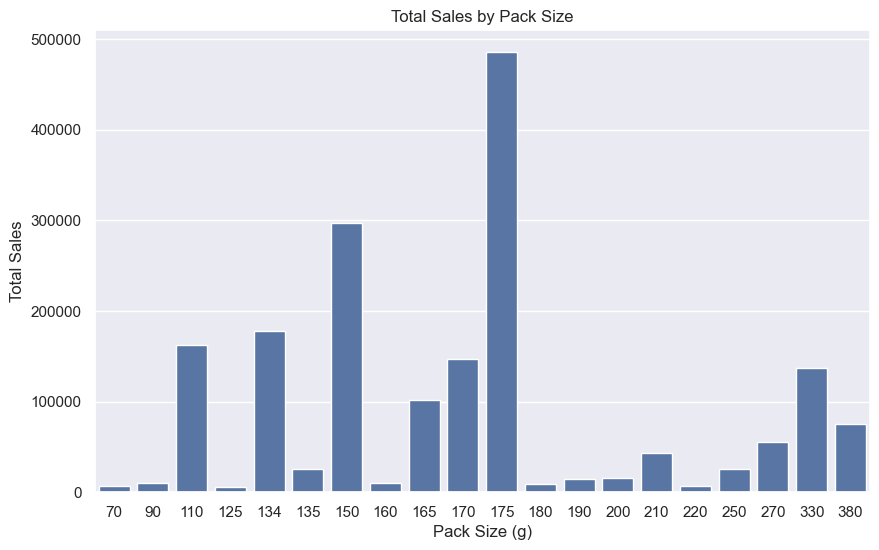

In [95]:
# What pack size is most popular among customers?
pack_size = transactions.groupby('PACK_SIZE')['TOT_SALES'].sum().reset_index()
pack_size = pack_size.sort_values(by='TOT_SALES', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='PACK_SIZE', y='TOT_SALES', data=pack_size)
plt.title('Total Sales by Pack Size')
plt.xlabel('Pack Size (g)')
plt.ylabel('Total Sales')
plt.show()

### Brand Name
Extracting the brand from the product name and standardizing inconsistent brand spellings to ensure accurate analysis.

In [96]:
# Extract brand name
transactions['BRAND'] = transactions['PROD_NAME'].str.split().str[0]
print(transactions['BRAND'].unique())

#Fix the brand names to be more consistent
transactions['BRAND'] = transactions['BRAND'].replace({
    'Dorito': 'Doritos',
    'Natural' : 'Natural Chip Co',
    'Smith': 'Smiths',
    'RRD': 'Red Rock Deli',
    'Red' : 'Red Rock Deli',
    'Snbts': 'Sunbites',
    'NCC': 'Natural Chip Co',
    'Infzns': 'Infuzions',
    'GrnWves':'Grain Waves',
    'Grain':'Grain Waves',
    'WW' : 'Woolworths',
})

print('Updated brand names:\n', transactions['BRAND'].unique())

['Natural' 'CCs' 'Smiths' 'Kettle' 'Grain' 'Doritos' 'Twisties' 'WW'
 'Thins' 'Burger' 'NCC' 'Cheezels' 'Infzns' 'Red' 'Pringles' 'Dorito'
 'Infuzions' 'Smith' 'GrnWves' 'Tyrrells' 'Cobs' 'French' 'RRD' 'Tostitos'
 'Cheetos' 'Woolworths' 'Snbts' 'Sunbites']
Updated brand names:
 ['Natural Chip Co' 'CCs' 'Smiths' 'Kettle' 'Grain Waves' 'Doritos'
 'Twisties' 'Woolworths' 'Thins' 'Burger' 'Cheezels' 'Infuzions'
 'Red Rock Deli' 'Pringles' 'Tyrrells' 'Cobs' 'French' 'Tostitos'
 'Cheetos' 'Sunbites']


## Merging Datasets
Combining transaction data with customer segment data on loyalty card number to enable segment-level analysis.

In [97]:
# merge trnsactions and customers datasets on LYLTY_CARD_NBR
merged_data = pd.merge(transactions, customers, on='LYLTY_CARD_NBR', how='inner')
print(merged_data.head())

print('\n')
print(merged_data.isnull().sum())
print('Unique customers:', merged_data['LYLTY_CARD_NBR'].nunique())
print('Unique lifestages:', merged_data['LIFESTAGE'].unique())
print('Unique premium segments:', merged_data['PREMIUM_CUSTOMER'].unique())


                           DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0 1970-01-01 00:00:00.000043390          1            1000       1         5   
1 1970-01-01 00:00:00.000043599          1            1307     348        66   
2 1970-01-01 00:00:00.000043605          1            1343     383        61   
3 1970-01-01 00:00:00.000043329          2            2373     974        69   
4 1970-01-01 00:00:00.000043330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  PACK_SIZE  \
0    Natural Chip        Compny SeaSalt175g         2        6.0        175   
1                  CCs Nacho Cheese    175g         3        6.3        175   
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9        170   
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0        175   
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8        150   

             BRAND               LIFESTAGE P

## Customer Segment Analysis

### Total Sales by Segment
Investigating which customer segments contribute most to total chip revenue.

                 LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
6           OLDER FAMILIES           Budget  157612.95
19   YOUNG SINGLES/COUPLES       Mainstream  147999.20
13                RETIREES       Mainstream  145837.35
15          YOUNG FAMILIES           Budget  130352.25
9    OLDER SINGLES/COUPLES           Budget  128130.00
10   OLDER SINGLES/COUPLES       Mainstream  125178.10
11   OLDER SINGLES/COUPLES          Premium  124073.05
12                RETIREES           Budget  106276.00
7           OLDER FAMILIES       Mainstream   96927.25
14                RETIREES          Premium   91668.55
16          YOUNG FAMILIES       Mainstream   86809.25
1   MIDAGE SINGLES/COUPLES       Mainstream   85028.75
17          YOUNG FAMILIES          Premium   78853.90
8           OLDER FAMILIES          Premium   75639.80
18   YOUNG SINGLES/COUPLES           Budget   57307.80
2   MIDAGE SINGLES/COUPLES          Premium   54852.55
20   YOUNG SINGLES/COUPLES          Premium   39171.10
0   MIDAGE

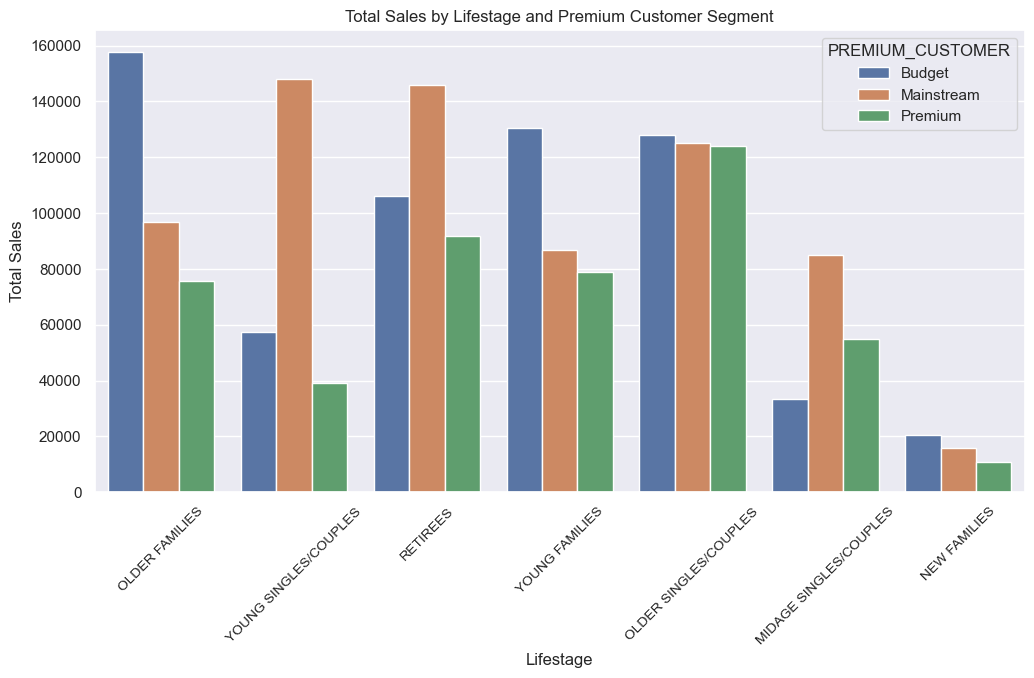

<Figure size 640x480 with 0 Axes>

In [112]:
# Analysis of which segmments spend the most on chips 
segment_sales = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
segment_sales = segment_sales.sort_values(by='TOT_SALES', ascending=False)
print(segment_sales)
plt.figure(figsize=(12, 6))
sns.barplot(x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER', data=segment_sales)
plt.title('Total Sales by Lifestage and Premium Customer Segment')
plt.xlabel('Lifestage')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, fontsize=10)
plt.show()
plt.savefig('segment_sales.png', bbox_inches='tight', dpi=150)

### Sales per Customer
Total sales alone can be misleading because a segment with more customers will naturally spend more overall. A normalizing approach was employed to reveal which segments spend the most per person.

                 LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES  NUM_CUSTOMERS  \
8           OLDER FAMILIES       Mainstream   96927.25           2790   
0           OLDER FAMILIES           Budget  157612.95           4617   
13          OLDER FAMILIES          Premium   75639.80           2238   
3           YOUNG FAMILIES           Budget  130352.25           3959   
12          YOUNG FAMILIES          Premium   78853.90           2403   
10          YOUNG FAMILIES       Mainstream   86809.25           2691   
6    OLDER SINGLES/COUPLES          Premium  124073.05           4692   
4    OLDER SINGLES/COUPLES           Budget  128130.00           4856   
11  MIDAGE SINGLES/COUPLES       Mainstream   85028.75           3300   
5    OLDER SINGLES/COUPLES       Mainstream  125178.10           4866   

    AVG_SALES_PER_CUSTOMER  
8                34.740950  
0                34.137524  
13               33.797945  
3                32.925549  
12               32.814773  
10               32.25

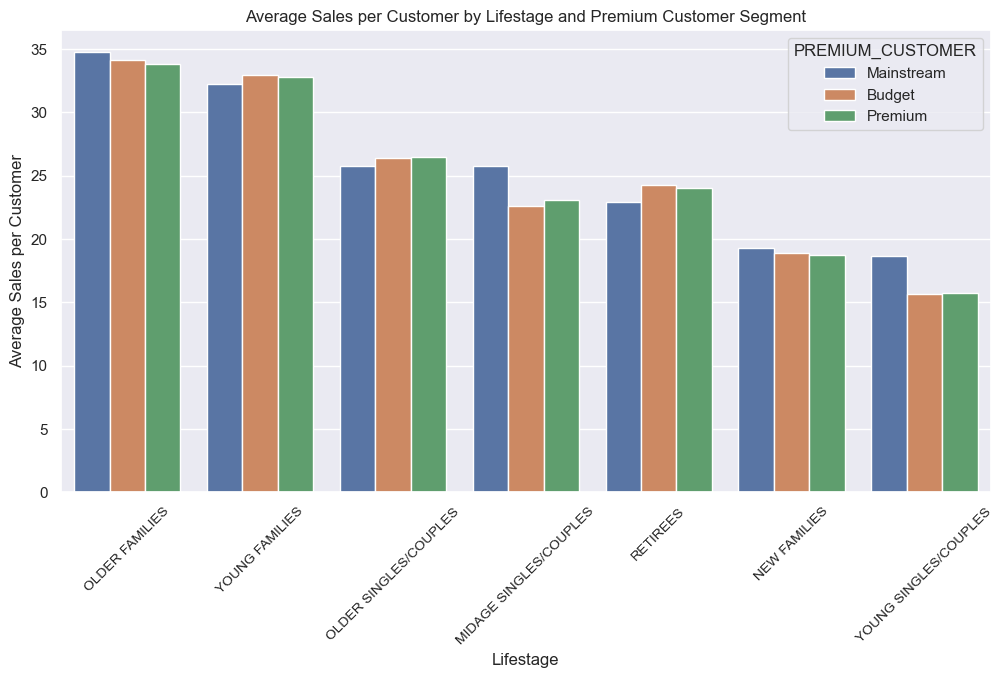

In [99]:
# Normalise the total sales by the number of customers in each segment to get average sales per customer
segment_customers = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
segment_customers.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'NUM_CUSTOMERS']

segment_analysis = pd.merge(segment_sales, segment_customers, on=['LIFESTAGE', 'PREMIUM_CUSTOMER'])
segment_analysis['AVG_SALES_PER_CUSTOMER'] = segment_analysis['TOT_SALES'] / segment_analysis['NUM_CUSTOMERS']
segment_analysis = segment_analysis.sort_values(by='AVG_SALES_PER_CUSTOMER', ascending=False)
print(segment_analysis.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x='LIFESTAGE', y='AVG_SALES_PER_CUSTOMER', hue='PREMIUM_CUSTOMER', data=segment_analysis)
plt.title('Average Sales per Customer by Lifestage and Premium Customer Segment')
plt.xlabel('Lifestage')
plt.ylabel('Average Sales per Customer')
plt.xticks(rotation=45, fontsize=10)
plt.show()

### Average Bags per Customer
Looking at how many bags of chips each segment buys per year to understand volume-driven vs price-driven sales differences.

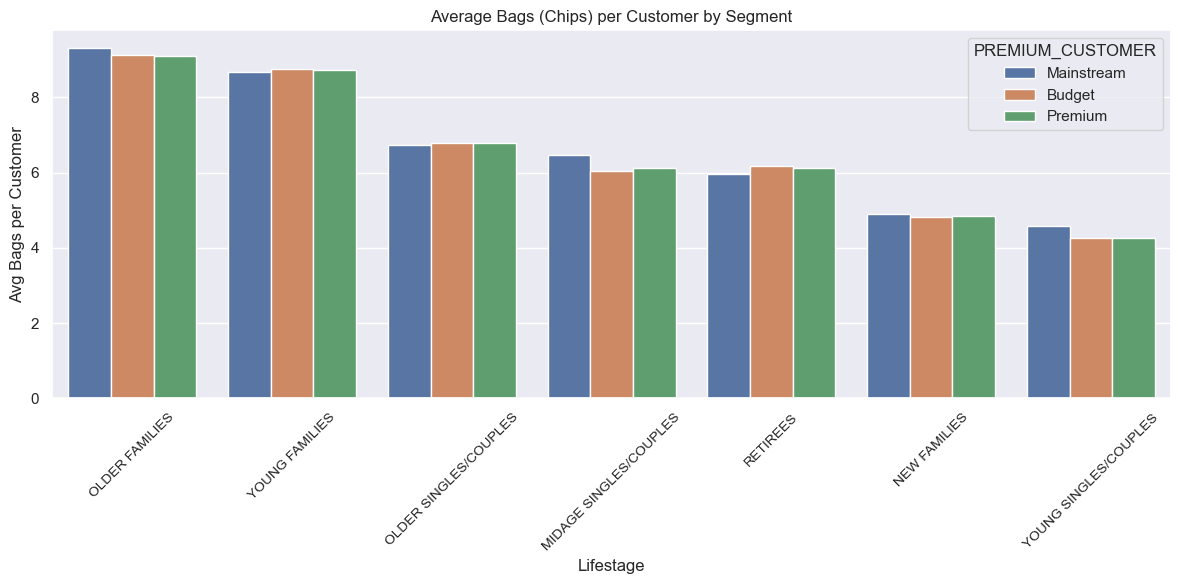

In [101]:
# Average number of chips (bags) bought per customer by segment
bags_per_customer = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    TOTAL_BAGS = ('PROD_QTY', 'sum'),
    NUM_CUSTOMERS = ('LYLTY_CARD_NBR','nunique')
).reset_index()

bags_per_customer['AVG_BAGS_PER_CUSTOMER'] = bags_per_customer['TOTAL_BAGS'] / bags_per_customer['NUM_CUSTOMERS']
bags_per_customer = bags_per_customer.sort_values('AVG_BAGS_PER_CUSTOMER', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='LIFESTAGE', y='AVG_BAGS_PER_CUSTOMER', hue='PREMIUM_CUSTOMER', data=bags_per_customer)
plt.title('Average Bags (Chips) per Customer by Segment')
plt.xlabel('Lifestage')
plt.ylabel('Avg Bags per Customer')
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()

Brand affinity for Mainstream Young Singles/Couples:
BRAND
Tyrrells       1.237735
Twisties       1.225059
Doritos        1.212515
Tostitos       1.207636
Kettle         1.195322
Pringles       1.182899
Cobs           1.139426
Infuzions      1.123804
Grain Waves    1.060291
Thins          1.051695
Name: LYLTY_CARD_NBR, dtype: float64


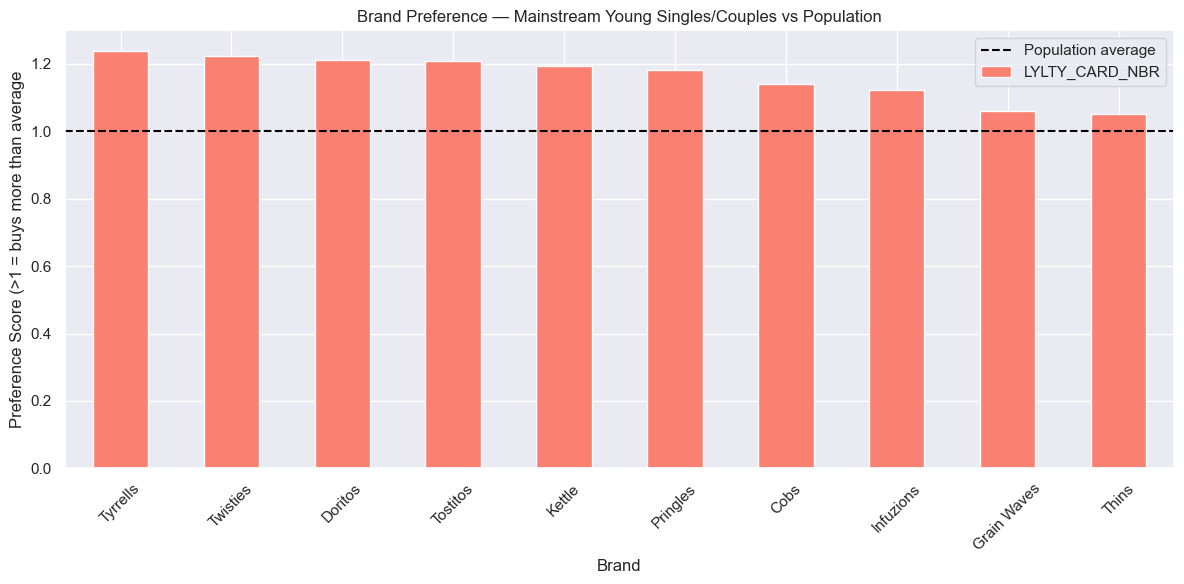

<Figure size 640x480 with 0 Axes>

In [113]:
# Brand preference - Mainstream Young Singles/Couples vs rest of population
target = merged_data[
    (merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & 
    (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream')
]
other = merged_data[~(
    (merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & 
    (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream')
)]

# Brand share within each group
target_brand = target.groupby('BRAND')['LYLTY_CARD_NBR'].count() / len(target)
other_brand = other.groupby('BRAND')['LYLTY_CARD_NBR'].count() / len(other)

# How much more likely this segment buys a brand vs everyone else
brand_preference = (target_brand / other_brand).sort_values(ascending=False)
print('Brand affinity for Mainstream Young Singles/Couples:')
print(brand_preference.head(10))

plt.figure(figsize=(12, 6))
brand_preference.head(10).plot(kind='bar', color = 'salmon')
plt.title('Brand Preference — Mainstream Young Singles/Couples vs Population')
plt.xlabel('Brand')
plt.ylabel('Preference Score (>1 = buys more than average')
plt.xticks(rotation=45)
plt.axhline(y=1, color='black', linestyle='--', label='Population average')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('brand_preference.png', bbox_inches='tight', dpi=150)

Pack size preference for Mainstream Young Singles/Couples:
PACK_SIZE
270    1.274312
380    1.258866
330    1.226443
134    1.182899
210    1.177433
110    1.174313
135    1.138058
250    1.128481
170    0.996226
150    0.957800
175    0.947708
165    0.903920
190    0.605282
180    0.583008
160    0.524409
90     0.517489
70     0.507992
125    0.492449
200    0.485372
220    0.480624
Name: LYLTY_CARD_NBR, dtype: float64


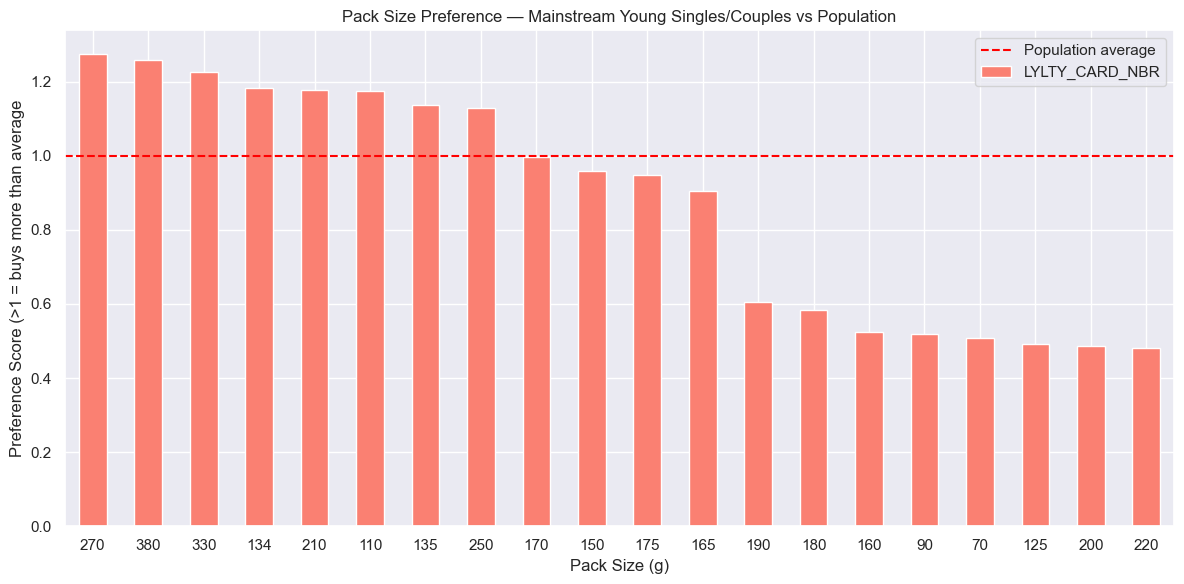

In [105]:
# Pack size preference 
target_pack = target.groupby('PACK_SIZE')['LYLTY_CARD_NBR'].count() / len(target)
other_pack = other.groupby('PACK_SIZE')['LYLTY_CARD_NBR'].count() / len(other)

pack_preference = (target_pack / other_pack).sort_values(ascending=False)
print('Pack size preference for Mainstream Young Singles/Couples:')
print(pack_preference)

plt.figure(figsize=(12, 6))
pack_preference.plot(kind='bar', color = 'salmon')
plt.title('Pack Size Preference — Mainstream Young Singles/Couples vs Population')
plt.xlabel('Pack Size (g)')
plt.ylabel('Preference Score (>1 = buys more than average')
plt.xticks(rotation=0)
plt.axhline(y=1, color='red', linestyle='--', label='Population average')
plt.legend()
plt.tight_layout()
plt.show()

### Mainstream Young Singles/Couples Analysis
Young Singles/Couples make up second of the most total sales but the least in sales per customer suggesting potential for growth, so a deep analysis was conducted too see the purchasing behavior of the Young Singles/Couples.

Mainstream Young Singles/Couples buy more than the population average on specific brands showed by the plot, so these brands should always be in stock and in the front of the shelf. Furthermore, Young Singles/Couples buy either really big bags or really small ones, suggesting that the purchsasing behavior of chips relies on big occasions such as parties or individual snacking size bags.

These two findings show a clear insight for the store owners to come up with a way to push certains brands and certain bag sizes to take advantage of the potential growth in sales in the Young Singles/Couples segment.